Benjamin Arnold, 09/06/2026, Lab 2-- Energy-Tracking Projectile

Part A: Adding Energy Tracking

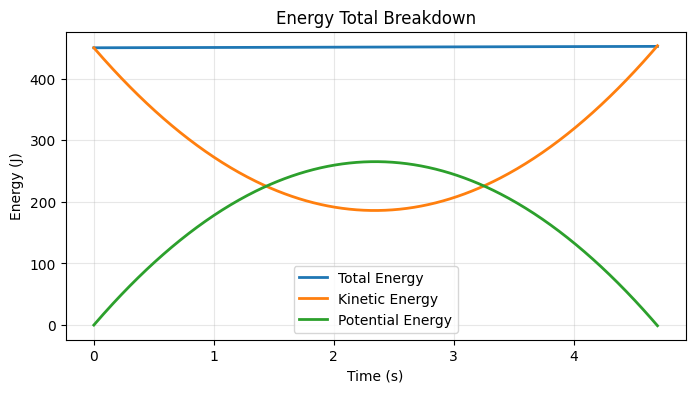

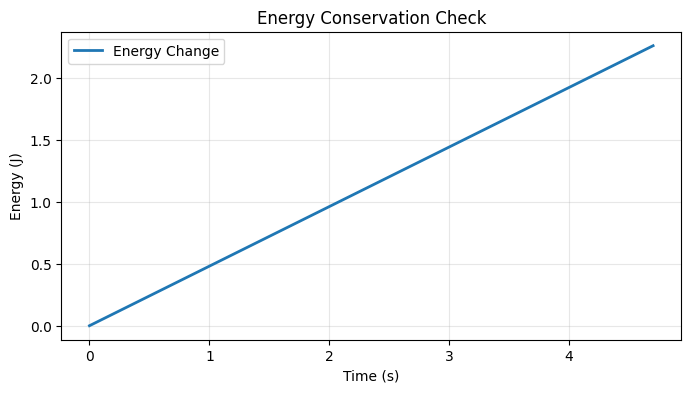

Energy Percentage Drift: 0.5014970099999674%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Useful Constants--------------------------------------------------------------------------------------
time_step=0.01
initial_velocity=30.0
initial_angle=50.0
g=9.81
m=1.0

#Function for simulating trajectories in 2d---------------------------------------------------------------
def simulate_projectile_2d(v0,theta_deg,dt,g=g,m=m):
    ay,ax=-g,0
    vx=v0*np.cos(theta_deg*np.pi/180)
    vy=v0*np.sin(theta_deg*np.pi/180)

    x,y,t=0.0,0.0,0.0

    KE=(0.5*m)*(vx**2+vy**2)
    PE=(m*g)*y
    E=KE+PE
    
    t_arr,x_arr,y_arr,vy_arr,vx_arr,E_arr,KE_arr,PE_arr=[t],[x],[y],[vy],[vx],[E],[KE],[PE]

    while (y>=0):
        x=x+vx*dt
        y=y+vy*dt
        vx=vx+ax*dt
        vy=vy+ay*dt
        t=t+dt

        KE=(0.5*m)*(vx**2+vy**2)
        PE=(m*g)*y
        E=KE+PE

        t_arr.append(t)
        x_arr.append(x)
        y_arr.append(y)
        vy_arr.append(vy)
        vx_arr.append(vx)
        E_arr.append(E)
        KE_arr.append(KE)
        PE_arr.append(PE)
    return t_arr,x_arr,y_arr,vx_arr,vy_arr,E_arr,KE_arr,PE_arr

#unpacking
t,x,y,vx,vy,E,KE,PE=simulate_projectile_2d(initial_velocity,initial_angle,time_step,g=g,m=m)

#plotting
plt.figure(figsize=(8, 4))
plt.plot(t, E, linewidth=2, label='Total Energy')
plt.plot(t, KE, linewidth=2, label='Kinetic Energy')
plt.plot(t, PE, linewidth=2, label='Potential Energy')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Energy Total Breakdown')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, (E-E[0]), linewidth=2, label='Energy Change')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Energy Conservation Check')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#percentage drift for Euler method
print(f'Energy Percentage Drift: {((E[-2]-E[0])/E[0])*100}%')


Interpretation: With the Euler Method, and without drag, the energy drifts upward linearly, gaining about half a percent of error every 5 seconds or so. The drift seems to be perfectly constant, and does not accelerate.

Part B: Euler Vs. Euler-Cromer

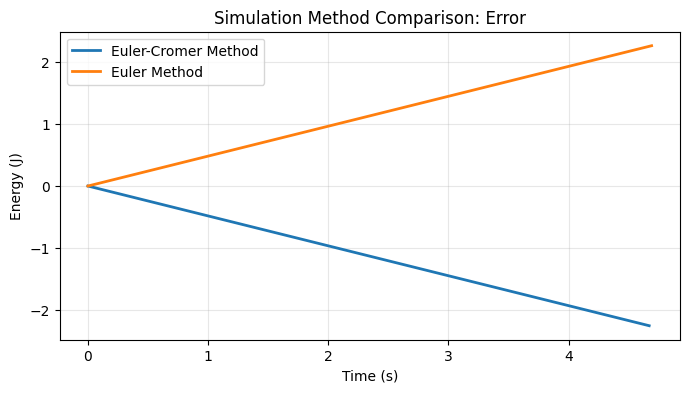

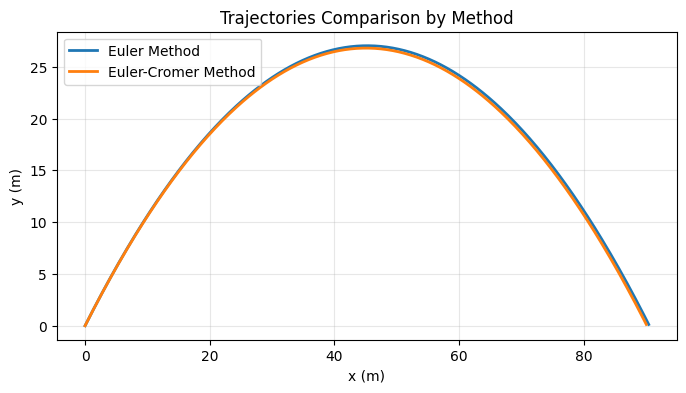

The range for the Euler method is 90.44021668289608 meters, and the range for the Euler-Cromer method is 90.05454411708416 meters. A difference of 0.385672565811916 meters.
Energy Percentage Drift (Euler): 0.5014970099999674%
Energy Percentage Drift (Euler-Cromer): -0.4993584300000167%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Useful Constants--------------------------------------------------------------------------------------
time_step=0.01
initial_velocity=30.0
initial_angle=50.0
g=9.81
m=1.0
max_time=15

#Function for simulating trajectories in 2d, with energy tracking.
#The method is a Boolean: input 1 for Euler-Cromer, 0 for Euler.
def simulate(method,v0,theta_deg,dt,g=g,m=m):
    ay,ax=-g,0
    vx=v0*np.cos(theta_deg*np.pi/180)
    vy=v0*np.sin(theta_deg*np.pi/180)

    x,y,t=0.0,0.0,0.0

    KE=(0.5*m)*(vx**2+vy**2)
    PE=(m*g)*y
    E=KE+PE
    
    t_arr,x_arr,y_arr,vy_arr,vx_arr,E_arr,KE_arr,PE_arr=[t],[x],[y],[vy],[vx],[E],[KE],[PE]

    while (t<=max_time):
        if (method==1):
            vx=vx+ax*dt
            vy=vy+ay*dt
            x=x+vx*dt
            y=y+vy*dt
        elif(method==0):
            x=x+vx*dt
            y=y+vy*dt
            vx=vx+ax*dt
            vy=vy+ay*dt
            
        if (y<0): break

        KE=(0.5*m)*(vx**2+vy**2)
        PE=(m*g)*y
        E=KE+PE

        t=t+dt

        t_arr.append(t)
        x_arr.append(x)
        y_arr.append(y)
        vy_arr.append(vy)
        vx_arr.append(vx)
        E_arr.append(E)
        KE_arr.append(KE)
        PE_arr.append(PE)
    return t_arr,x_arr,y_arr,vx_arr,vy_arr,E_arr,KE_arr,PE_arr

#unpacking
t1,x1,y1,vx1,vy1,E1,KE1,PE1=simulate(1,initial_velocity,initial_angle,time_step,g=g,m=m)
t,x,y,vx,vy,E,KE,PE=simulate(0,initial_velocity,initial_angle,time_step,g=g,m=m)

#plotting
plt.figure(figsize=(8, 4))
plt.plot(t1, (E1-E1[0]), linewidth=2, label='Euler-Cromer Method')
plt.plot(t, (E-E[0]), linewidth=2, label='Euler Method')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Simulation Method Comparison: Error')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(x, y, linewidth=2, label='Euler Method')
plt.plot(x1, y1, linewidth=2, label='Euler-Cromer Method')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Trajectories Comparison by Method')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#Reporting range and percentage drift for each method
print(f'The range for the Euler method is {np.max(x)} meters, and the range for the Euler-Cromer method is {np.max(x1)} meters.\
 A difference of {np.max(x)-np.max(x1)} meters.')

print(f'Energy Percentage Drift (Euler): {((E[-1]-E[0])/E[0])*100}%')
print(f'Energy Percentage Drift (Euler-Cromer): {((E1[-1]-E1[0])/E1[0])*100}%')

Interpretation: In the actual physical world, position and velocity "update" at the same time. But when simulating, we have to choose a discrete time-step by which to progress our simulation, which introduces a problem: should we update velocity or position first? If we choose to update position first (Euler Method), then we use the old velocity, which overshoots systematically because in reality the velocity is continually decreasing (due to gravity in this case). But if we choose to update velocity first (Euler-Cromer Method), then we choose the new velocity, which undershoots systematically for the same reason but opposite sign. 

Part C: Convergence Study

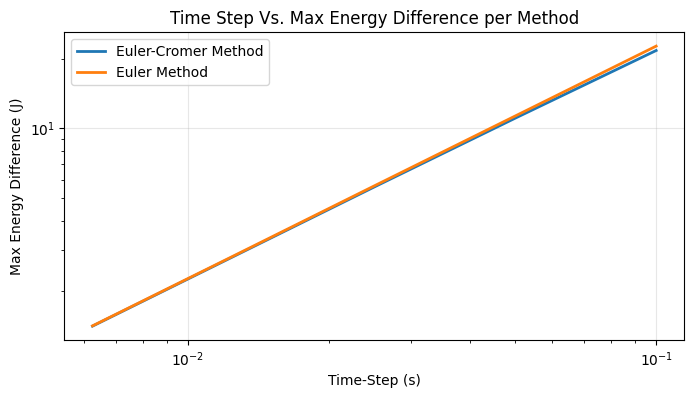

Euler-Cromer Method Order p: 0.9870447408686109
Euler Method Order p: 1.0011526198882996


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Useful Constants--------------------------------------------------------------------------------------
initial_velocity=30.0
initial_angle=50.0
g=9.81
m=1.0

#Arrays and for loop for each method's energy calculations (Again, 1 for Cromer).
E1_diff=[]
E_diff=[]
time=[0.1, 0.05, 0.025, 0.0125, 0.00625]
for dt in time:
    E1=simulate(1,initial_velocity,initial_angle,dt,g=g,m=m)[5]
    E1_diff.append(np.max(np.abs(E1[0]-E1)))

    E=simulate(0,initial_velocity,initial_angle,dt,g=g,m=m)[5]
    E_diff.append(np.max(np.abs(E[0]-E)))

#I turned these into arrays for the polyfit() function
time_arr = np.array(time)
E1_diff_arr = np.array(E1_diff)
E_diff_arr = np.array(E_diff)

#plotting
plt.figure(figsize=(8, 4))
plt.loglog(time_arr, E1_diff_arr, linewidth=2, label='Euler-Cromer Method')
plt.loglog(time_arr, E_diff_arr, linewidth=2, label='Euler Method')
plt.xlabel('Time-Step (s)')
plt.ylabel('Max Energy Difference (J)')
plt.title('Time Step Vs. Max Energy Difference per Method')
plt.grid(True, alpha=0.3)
plt.legend()
slope1=np.polyfit(np.log(time_arr), np.log(E1_diff_arr), 1)[0]
slope=np.polyfit(np.log(time_arr), np.log(E_diff_arr), 1)[0]
plt.show()

print(f"Euler-Cromer Method Order p: {slope1}")
print(f"Euler Method Order p: {slope}")

Interpretation: 
(a) The error for the Euler method grows with order 1. This matches expectation.

(b) The Euler-Cromer method has an error that grows very nearly to order 1, but it is slightly less than Euler for larger time steps. The two, on this graph, are virtuall indistinuishable for small enough time-step. Though this is entirely expected, since as t goes to zero, there is no "old" and "new" velocity.

(c) To minimize energy drift, one should simply choose a very small time-step. For dt=0.0001, the energy drift is 0.005%, which is miniscule. The two methods converge quite closely at small time-steps, but at large time-steps, the Euler-Cromer method has the advantage, although slight. However, if one's time-step is large, e.g. dt=0.1, then the energy drift will be significant either way, at roughly 5%. Nevertheless, the Euler-Cromer method does systematically beat out the standard Euler method per time-step; here are some values where I will report the time-step and the percentage difference between them, where I have taken the absolute value of the Euler-Cromer percentage (P=Euler Percent Drift minus Euler-Cromer Percent Drift): dt=1, P~20%; dt=0.1, P~0.2%; dt=0.01, P~0.01%; dt=0.001, P~0.00002%; etc. 